In [ ]:
#Import Libraries
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
#Load Data
X_train = pd.read_csv("../data/model_input/X_train.csv")
X_test = pd.read_csv("../data/model_input/X_test.csv")

y_train = pd.read_csv("../data/model_input/y_train.csv").squeeze()
y_test = pd.read_csv("../data/model_input/y_test.csv").squeeze()

In [ ]:
#Creating the model
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [ ]:
#Training the model
dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [ ]:
##Make predictions
y_pred = dt_model.predict(X_test)

In [ ]:
#Model evaluation
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8066666666666666


In [ ]:
#Precision
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 0.8065882272296974


In [ ]:
#Recall
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

Recall: 0.8066666666666666


In [ ]:
#F1 Score
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score:", f1)

F1 Score: 0.8065308169338101


In [ ]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.83      0.85      0.84       200
         Low       0.88      0.86      0.87       202
      Medium       0.71      0.70      0.71       198

    accuracy                           0.81       600
   macro avg       0.81      0.81      0.81       600
weighted avg       0.81      0.81      0.81       600



In [17]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[171   0  29]
 [  0 174  28]
 [ 35  24 139]]


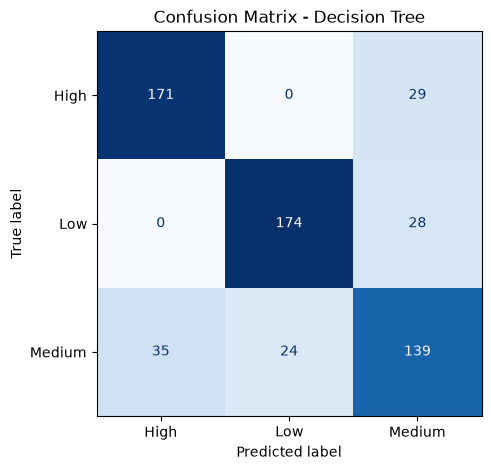

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [12]:
#Feature importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
7,bacteria_count,0.487013
1,contaminant_level,0.179053
9,infant_mortality_rate,0.087117
13,sanitation_coverage,0.068075
3,turbidity,0.059448
6,lead,0.021546
8,clean_water_access,0.017797
16,population_density,0.015829
5,nitrate,0.014602
11,healthcare_access,0.010550


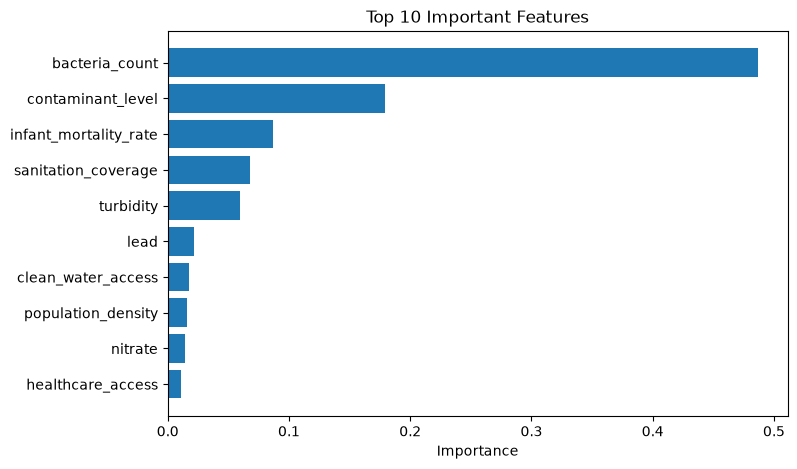

In [13]:
#Plot for feature importance
top_features = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
#Model saving
joblib.dump(
    dt_model,
    "../models/decision_tree.pkl"
)

['../models/decision_tree.pkl']

In [ ]:
#Results Table
results_dt = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results_dt

,Metric,Value
0,Accuracy,0.806667
1,Precision,0.806588
2,Recall,0.806667
3,F1 Score,0.806531


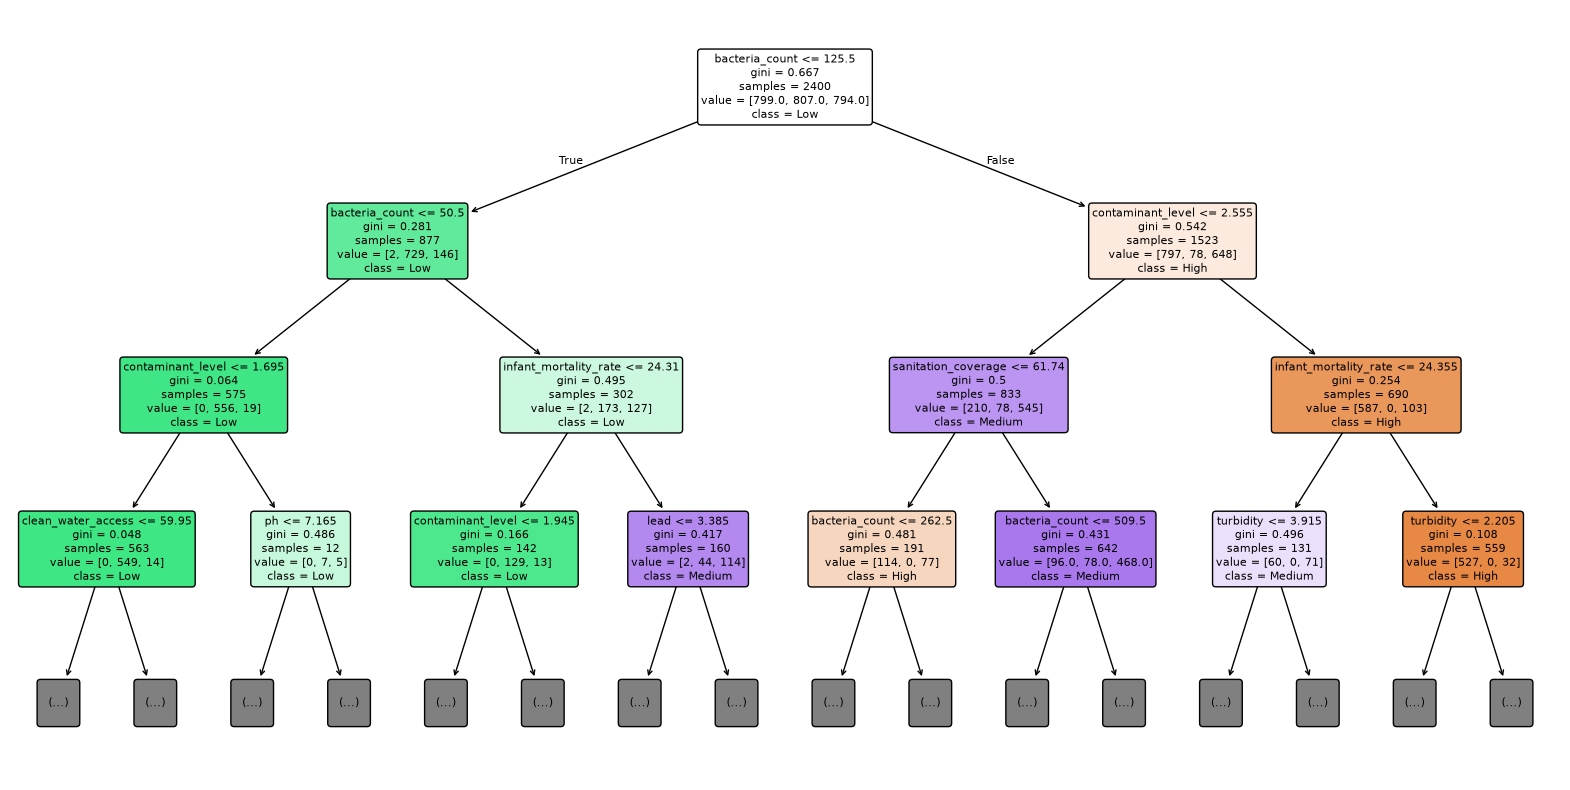

In [ ]:
#First few levels of the tree
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
##Checking the training and testing accuracy
dt_train_accuracy = dt_model.score(X_train,y_train)

dt_test_accuracy = dt_model.score(X_test,y_test)

print("Training Accuracy:",dt_train_accuracy)
print("Testing Accuracy:",dt_test_accuracy)

Training Accuracy: 0.9370833333333334
Testing Accuracy: 0.8066666666666666
